# Data Wrangling

This notebook prepares the dataset for modeling by transforming cleaned relational tables into an analysis-ready format.

The process includes:
- Data validation
- Feature engineering
- Dataset integration

In [42]:
import pandas as pd
import numpy as np
import sqlite3

## Load Data from Database

We load the cleaned tables from the SQLite database created in Milestone 1.

In [43]:
conn = sqlite3.connect("../humanitarian.db")

crises_df = pd.read_sql("SELECT * FROM crises", conn)
monthly_df = pd.read_sql("SELECT * FROM monthly_coverage", conn)
outlet_df = pd.read_sql("SELECT * FROM coverage_by_outlet", conn)
framing_df = pd.read_sql("SELECT * FROM framing", conn)
sentiment_df = pd.read_sql("SELECT * FROM sentiment", conn)
victim_df = pd.read_sql("SELECT * FROM victim_causor", conn)

## Data Validation

We perform quick checks to ensure data consistency before transformation.

In [44]:
tables = {
    "crises": crises_df,
    "monthly": monthly_df,
    "outlet": outlet_df,
    "framing": framing_df,
    "sentiment": sentiment_df,
    "victim": victim_df
}

for name, df in tables.items():
    print(f"{name} shape:", df.shape)
    print(f"{name} duplicates:", df.duplicated().sum())
    print("-" * 40)

crises shape: (10, 10)
crises duplicates: 0
----------------------------------------
monthly shape: (734, 4)
monthly duplicates: 0
----------------------------------------
outlet shape: (403, 7)
outlet duplicates: 0
----------------------------------------
framing shape: (471, 7)
framing duplicates: 0
----------------------------------------
sentiment shape: (430, 7)
sentiment duplicates: 0
----------------------------------------
victim shape: (348, 7)
victim duplicates: 0
----------------------------------------


# Feature Engineering

## Framing Ratios

We calculate the proportion of each framing type per crisis to identify dominant narratives.

In [45]:
# Only calculate framing ratios for crises that have framing data
# Group by crisis_id and framing_type, sum raw_count
framing_counts = framing_df.groupby(['crisis_id', 'framing_type'])['raw_count'].sum().reset_index()

# Total mentions per crisis
total_mentions = framing_counts.groupby('crisis_id')['raw_count'].sum().reset_index()
total_mentions.rename(columns={'raw_count':'total_raw_count'}, inplace=True)

# Merge total back into framing_counts to compute ratio
framing_counts = framing_counts.merge(total_mentions, on='crisis_id')
framing_counts['framing_ratio'] = framing_counts['raw_count'] / framing_counts['total_raw_count']

framing_counts.head()

,crisis_id,framing_type,raw_count,total_raw_count,framing_ratio
0,5,economic,660,45128,0.014625
1,5,geopolitical,9598,45128,0.212684
2,5,humanitarian,18104,45128,0.401170
3,5,legal,1208,45128,0.026768
4,5,military,11456,45128,0.253856


## 5.3 Outlet Concentration

We compute the percentage of coverage contributed by the top 3 outlets per crisis.

This helps us understand whether media coverage is:
- **Concentrated** (few outlets dominate coverage)
- **Distributed** (many outlets contribute more evenly)

In [46]:
# Use outlet_clean (this contains ALL crises)

# Step 1: total coverage per crisis per outlet
outlet_counts = outlet_df.groupby(['crisis_id', 'outlet_name'])['coverage_count'].sum().reset_index()

# Step 2: function to compute top 3 outlet percentage
def top3_percentage(df):
    df_sorted = df.sort_values(by='coverage_count', ascending=False)
    top3_sum = df_sorted.head(3)['coverage_count'].sum()
    total_sum = df_sorted['coverage_count'].sum()
    return top3_sum / total_sum if total_sum > 0 else 0

# Step 3: apply per crisis
top3_list = []

for cid, group in outlet_counts.groupby('crisis_id'):
    top3_list.append({
        'crisis_id': cid,
        'top3_outlet_ratio': top3_percentage(group)
    })

top3_outlet_df = pd.DataFrame(top3_list)

top3_outlet_df.head()

,crisis_id,top3_outlet_ratio
0,1,0.211033
1,2,0.355301
2,3,0.453797
3,4,0.551952
4,5,0.173983


## 5.4 Merge Features into Master Table

We now combine all engineered features into a single master dataset.

This includes:
- Core crisis-level metrics (coverage, funding, affected people, duration)
- Framing ratios (limited to available crises)
- Outlet concentration (available for all crises)

Missing values are expected for framing-related features due to limited data availability. These are filled with 0 to maintain consistency for modeling.

In [47]:
# Start from crises_df (already has main features)
master_df = crises_df.copy()

# --- Merge framing ratios (limited data) ---
framing_pivot = framing_counts.pivot(
    index='crisis_id',
    columns='framing_type',
    values='framing_ratio'
).fillna(0)

# Rename columns for clarity
framing_pivot.columns = [f'framing_ratio_{col}' for col in framing_pivot.columns]

master_df = master_df.merge(framing_pivot, on='crisis_id', how='left')

# --- Merge outlet concentration ---
master_df = master_df.merge(top3_outlet_df, on='crisis_id', how='left')

# Fill missing values
master_df.fillna(0, inplace=True)

master_df.head()

,crisis_id,crisis_name,start_date,fund_required,people_affected,crisis_days,raw_coverage,coverage_per_day,coverage_per_funding,coverage_per_people,framing_ratio_economic,framing_ratio_geopolitical,framing_ratio_humanitarian,framing_ratio_legal,framing_ratio_military,framing_ratio_other,top3_outlet_ratio
0,1,Afghanistan,8/1/2021,3.04,22.9,1287,8302,6.450660,2730.921053,362.532751,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.211033
1,2,Chad,7/1/2009,1.50,7.8,5701,349,0.061217,232.666667,44.743590,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.355301
2,3,Democratic Republic of the Congo,3/1/2022,3.23,21.2,1075,1580,1.469767,489.164087,74.528302,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.453797
3,4,Ethiopia,11/1/2020,2.00,10.0,1560,1511,0.968590,755.500000,151.100000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.551952
4,5,Gaza and the Occupied Palestinian Territories,10/1/2023,4.00,3.3,496,29020,58.508065,7255.000000,8793.939394,0.014625,0.212684,0.40117,0.026768,0.253856,0.090897,0.173983


## 5.5 Feature Overview

The final master dataset includes:

**Core Features:**
- raw_coverage
- coverage_per_day
- coverage_per_funding
- coverage_per_people
- crisis_days
- fund_required
- people_affected

**Engineered Features:**
- framing_ratio_* (for available crises only)
- top3_outlet_ratio

This dataset is now structured for downstream analysis and modeling.

## 5.6 Correlation Analysis

We analyze relationships between numerical features to understand potential drivers of media coverage.

This step helps:
- Identify redundant features
- Detect strong relationships
- Inform feature selection for modeling

Note: Framing-related correlations are limited due to sparse data.

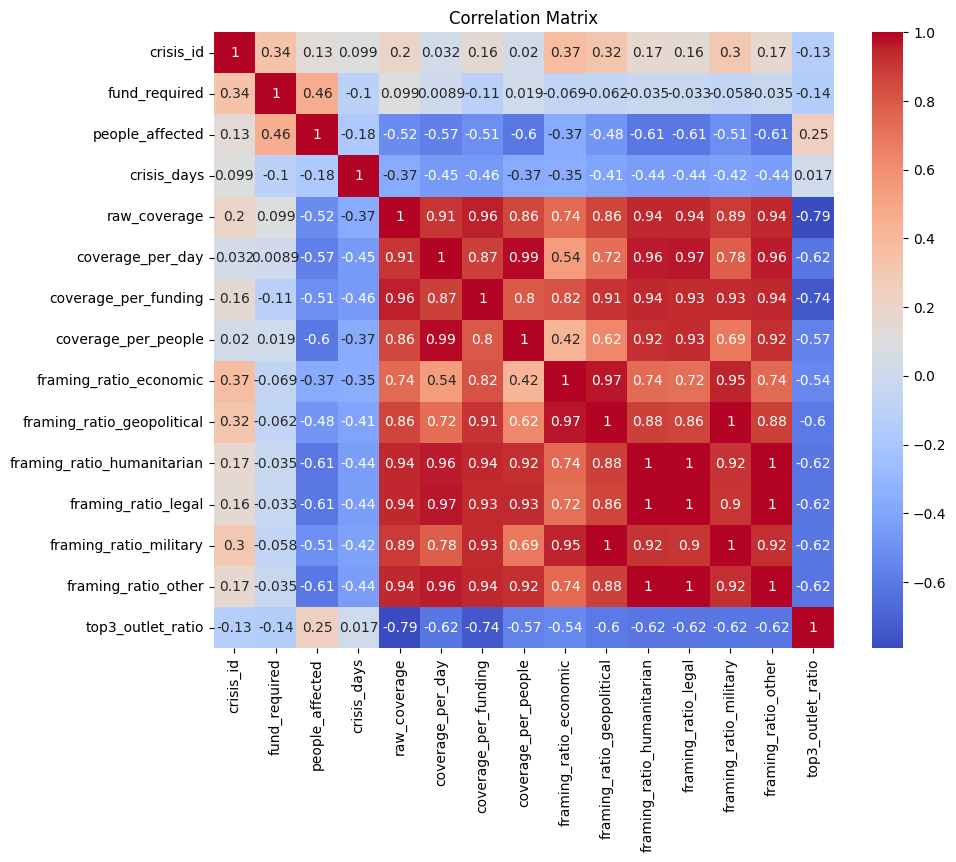

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_cols = master_df.select_dtypes(include=['int64', 'float64']).columns

corr_matrix = master_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## **Observations**

- **Strong correlation among coverage metrics:**  
  Variables such as *raw_coverage*, *coverage_per_day*, *coverage_per_funding*, and *coverage_per_people* show very high positive correlations (often above 0.85).  
  - These features capture similar information about **media attention intensity**.  
  - This indicates potential redundancy and suggests that not all of them are needed for modeling.

- **Weak or negative relationship with crisis severity indicators:**  
  - *people_affected* has a **negative correlation** with most coverage metrics.  
  - *crisis_days* also shows a moderate negative relationship.  
  - This suggests that **larger or longer crises do not necessarily receive more media attention**.

- **Funding shows mild positive correlation:**  
  - *fund_required* has a moderate positive relationship with coverage (~0.3–0.4).  
  - This implies funding needs may influence media attention, but not strongly.

- **Framing ratios are highly correlated with each other:**  
  - All framing ratio features show very high correlations (>0.9).  
  - This indicates **multicollinearity**, since these ratios are derived from the same base values.  
  - These features are not independent and may need to be reduced before modeling.

- **Framing vs coverage relationship:**  
  - Certain framing types (e.g., *humanitarian*, *geopolitical*) show strong positive correlations with coverage.  
  - This suggests **framing may influence media attention**, though further analysis is required.

- **Outlet concentration (top3_outlet_ratio):**  
  - Shows a **negative correlation** with coverage metrics.  
  - This implies crises covered by **more diverse outlets receive higher total attention**, while concentrated coverage leads to lower overall visibility.

---

## **Key Takeaways**

- Media attention is **not strongly driven by crisis severity alone**.
- Coverage-related variables are highly redundant.
- Framing and outlet distribution may play a **key role in explaining media bias**.
- Multicollinearity must be addressed before modeling.

## **Feature Overview**

Before proceeding to modeling, we review the final dataset structure.

This includes:
- Crisis-level attributes
- Engineered features (framing ratios, outlet concentration)

Each row represents a crisis with all relevant predictors.

In [49]:
master_df.head()

,crisis_id,crisis_name,start_date,fund_required,people_affected,crisis_days,raw_coverage,coverage_per_day,coverage_per_funding,coverage_per_people,framing_ratio_economic,framing_ratio_geopolitical,framing_ratio_humanitarian,framing_ratio_legal,framing_ratio_military,framing_ratio_other,top3_outlet_ratio
0,1,Afghanistan,8/1/2021,3.04,22.9,1287,8302,6.450660,2730.921053,362.532751,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.211033
1,2,Chad,7/1/2009,1.50,7.8,5701,349,0.061217,232.666667,44.743590,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.355301
2,3,Democratic Republic of the Congo,3/1/2022,3.23,21.2,1075,1580,1.469767,489.164087,74.528302,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.453797
3,4,Ethiopia,11/1/2020,2.00,10.0,1560,1511,0.968590,755.500000,151.100000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.551952
4,5,Gaza and the Occupied Palestinian Territories,10/1/2023,4.00,3.3,496,29020,58.508065,7255.000000,8793.939394,0.014625,0.212684,0.40117,0.026768,0.253856,0.090897,0.173983


## **Feature Selection**

Based on correlation analysis:

- Highly correlated coverage features indicate redundancy
- We retain one primary coverage variable: **raw_coverage**

Selected features:
- fund_required
- people_affected
- crisis_days
- top3_outlet_ratio
- selected framing ratios

This reduces noise and improves model interpretability.

In [50]:
model_df = master_df[[
    'crisis_id',
    'raw_coverage',
    'fund_required',
    'people_affected',
    'crisis_days',
    'top3_outlet_ratio',
    'framing_ratio_economic',
    'framing_ratio_geopolitical',
    'framing_ratio_humanitarian'
]]

model_df.head()

,crisis_id,raw_coverage,fund_required,people_affected,crisis_days,top3_outlet_ratio,framing_ratio_economic,framing_ratio_geopolitical,framing_ratio_humanitarian
0,1,8302,3.04,22.9,1287,0.211033,0.000000,0.000000,0.00000
1,2,349,1.50,7.8,5701,0.355301,0.000000,0.000000,0.00000
2,3,1580,3.23,21.2,1075,0.453797,0.000000,0.000000,0.00000
3,4,1511,2.00,10.0,1560,0.551952,0.000000,0.000000,0.00000
4,5,29020,4.00,3.3,496,0.173983,0.014625,0.212684,0.40117


## **Final Data Validation**

Before modeling, we verify:

- No missing values remain
- Data types are correct
- Dataset is ready for modeling

In [51]:
model_df.isnull().sum()

crisis_id                     0
raw_coverage                  0
fund_required                 0
people_affected               0
crisis_days                   0
top3_outlet_ratio             0
framing_ratio_economic        0
framing_ratio_geopolitical    0
framing_ratio_humanitarian    0
dtype: int64

## **Saving Clean Dataset**

The final dataset is saved to ensure reproducibility and separation between wrangling and modeling stages.

In [52]:
model_df.to_csv("../data/processed/cleaned_model_data.csv", index=False)
model_df.to_sql("model_data", conn, if_exists="replace", index=False)

10

## **Data Wrangling Summary**

In this stage, raw data was transformed into a structured dataset ready for modeling.

### Steps Completed:
- Data loading and validation
- Feature engineering:
  - Framing ratios
  - Outlet concentration
- Merging into a master dataset
- Handling missing values
- Correlation analysis
- Feature selection
- Final dataset creation

---

### Key Insights:
- Media coverage is not strongly aligned with crisis severity
- Coverage varies significantly across crises
- Framing and outlet distribution may influence visibility

---

### Next Step:
The cleaned dataset will be used for modeling to identify factors that explain media attention.